In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

In [6]:
df = pd.read_excel("../data/raw/Online_retail.xlsx")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
df['Sales'] = df['Quantity'] * df['UnitPrice']

In [9]:
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['Sales'].sum().reset_index()

In [10]:
daily_sales.columns = ['ds', 'y']

In [11]:
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

In [12]:
daily_sales = daily_sales.sort_values('ds')

In [13]:
daily_sales.head()

,ds,y
0,2010-12-01,58635.56
1,2010-12-02,46207.28
2,2010-12-03,45620.46
3,2010-12-05,31383.95
4,2010-12-06,53860.18


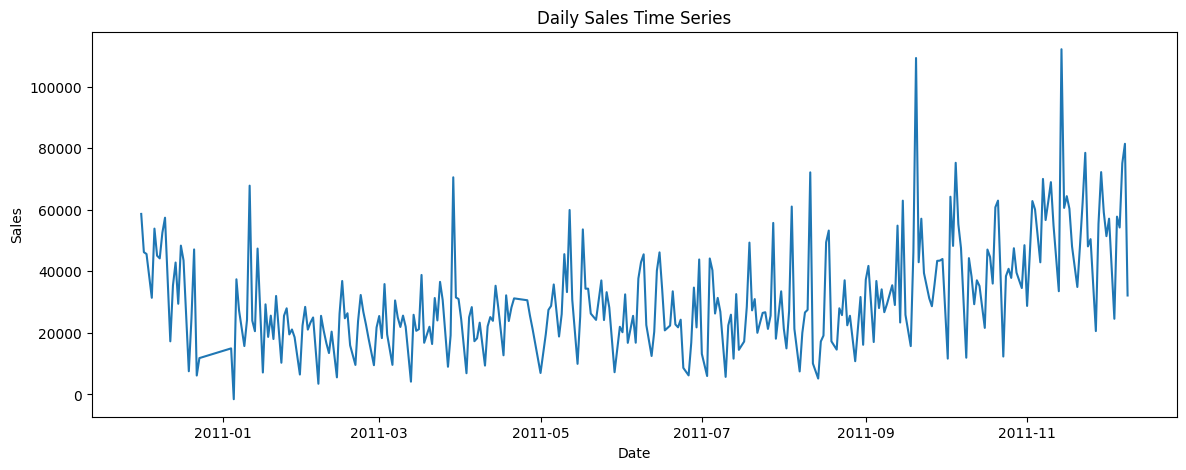

In [14]:
plt.figure(figsize=(14,5))

plt.plot(daily_sales['ds'],daily_sales['y'])

plt.title("Daily Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [15]:
daily_sales.isnull().sum()

ds    0
y     0
dtype: int64

In [16]:
daily_sales.index

RangeIndex(start=0, stop=305, step=1)

In [17]:
result = adfuller(daily_sales['y'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.2730443108471938
p-value: 0.6414125969787261


In [18]:
rolling_mean = daily_sales['y'].rolling(window=30).mean()

rolling_std = daily_sales['y'].rolling(window=30).std()

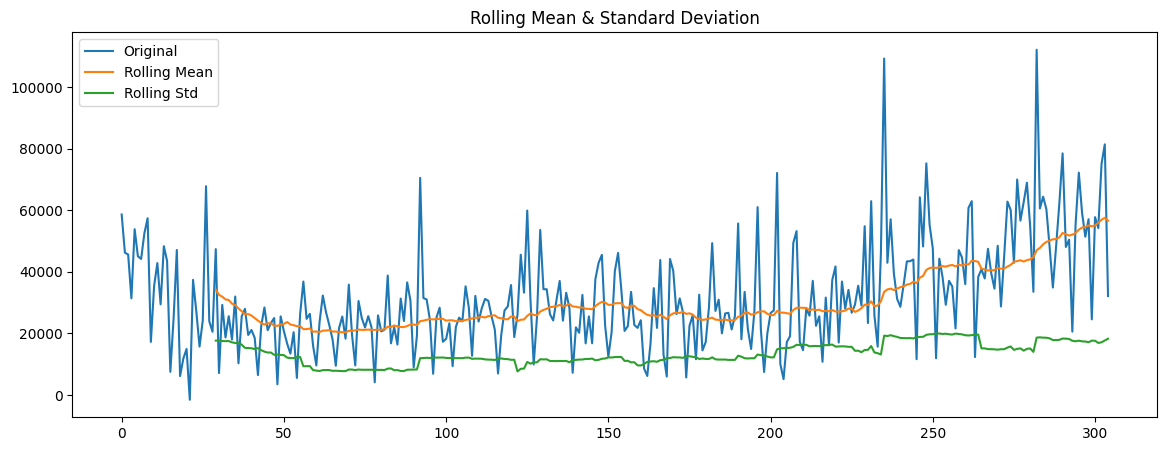

In [19]:
plt.figure(figsize=(14,5))

plt.plot(daily_sales['y'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')

plt.legend()

plt.title("Rolling Mean & Standard Deviation")

plt.show()

In [20]:
decomposition = seasonal_decompose(daily_sales['y'],model='additive',period=30)

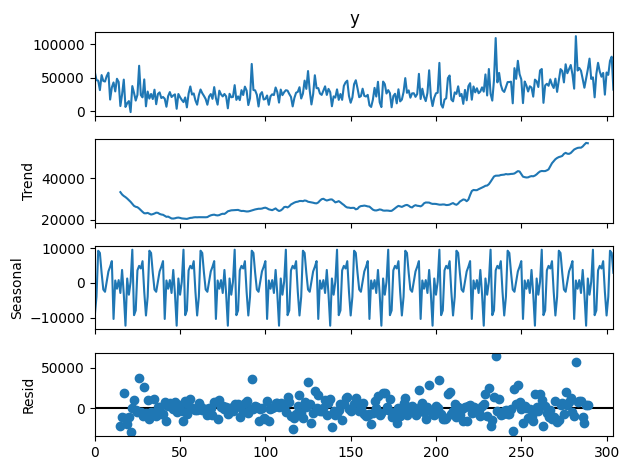

In [21]:
decomposition.plot()

plt.show()

In [22]:
daily_sales.columns = daily_sales.columns.str.lower()

In [23]:
daily_sales.to_csv("../data/processed/daily_sales.csv")